In [4]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd
import matplotlib.pyplot as plt

load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [2]:
query = """
select
    d.activity_id,
    d.activity_date,
    d.activity_type,
    d.trainer,
    d.moving_time_min,
    d.distance_km,
    d.elevation_gain_m,
    d.avg_speed_kph,
    d.avg_heartrate,
    d.avg_watts,
    d.weighted_avg_watts,
    d.efficiency_factor,
    d.decoupling,
    d.training_load,
    t.tsb,
    t.ctl,
    t.atl
from analytics.mart_activity_diary d
join analytics.int_training_load_daily t
    on t.calendar_date = d.activity_date
order by d.activity_date
"""

df = pd.read_sql(query, engine)
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   activity_id         126 non-null    object 
 1   activity_date       126 non-null    object 
 2   activity_type       126 non-null    object 
 3   trainer             40 non-null     object 
 4   moving_time_min     126 non-null    float64
 5   distance_km         51 non-null     float64
 6   elevation_gain_m    43 non-null     float64
 7   avg_speed_kph       56 non-null     float64
 8   avg_heartrate       121 non-null    float64
 9   avg_watts           41 non-null     float64
 10  weighted_avg_watts  40 non-null     float64
 11  efficiency_factor   38 non-null     float64
 12  decoupling          37 non-null     float64
 13  training_load       123 non-null    float64
 14  tsb                 125 non-null    float64
 15  ctl                 126 non-null    float64
 16  atl     

activity_id            0
activity_date          0
activity_type          0
trainer               86
moving_time_min        0
distance_km           75
elevation_gain_m      83
avg_speed_kph         70
avg_heartrate          5
avg_watts             85
weighted_avg_watts    86
efficiency_factor     88
decoupling            89
training_load          3
tsb                    1
ctl                    0
atl                    0
dtype: int64

n = 37
Pearson r = -0.119


<Axes: xlabel='tsb', ylabel='efficiency_factor'>

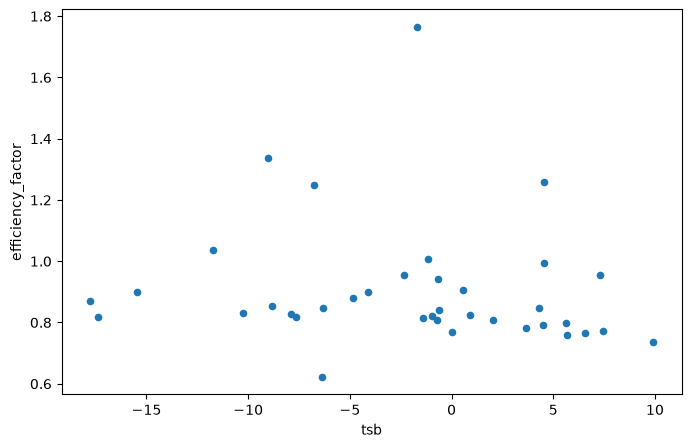

In [5]:
ef_df = df.dropna(subset=["efficiency_factor", "tsb"])
print(f"n = {len(ef_df)}")

correlation = ef_df["tsb"].corr(ef_df["efficiency_factor"])
print(f"Pearson r = {correlation:.3f}")

ef_df.plot.scatter(x="tsb", y="efficiency_factor", figsize=(8, 5))

In [6]:
speed_df = df.dropna(subset=["avg_speed_kph", "elevation_gain_m", "tsb"])
print(f"n = {len(speed_df)}")

n = 36


In [8]:
import numpy as np
from scipy import stats

def residualize(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    return y - (slope * x + intercept)

def partial_corr_test(y, x, control):
    y_resid = residualize(y, control)
    x_resid = residualize(x, control)
    r = np.corrcoef(x_resid, y_resid)[0, 1]
    n = len(y)
    df = n - 3
    t_stat = r * np.sqrt(df) / np.sqrt(1 - r**2)
    p = 2 * (1 - stats.t.cdf(abs(t_stat), df))
    return r, p, df

r_raw, p_raw = stats.pearsonr(speed_df["tsb"], speed_df["avg_speed_kph"])
print(f"raw r (speed vs TSB, elevation ignored)     = {r_raw:.3f}, p = {p_raw:.3f}")

r_partial, p_partial, df = partial_corr_test(
    speed_df["avg_speed_kph"], speed_df["tsb"], speed_df["elevation_gain_m"]
)
print(f"partial r (speed vs TSB, elevation controlled) = {r_partial:.3f}, p = {p_partial:.3f}, df = {df}")

raw r (speed vs TSB, elevation ignored)     = 0.118, p = 0.493
partial r (speed vs TSB, elevation controlled) = 0.216, p = 0.213, df = 33


## TSB vs Performance — Phase 2 findings (initial)

**Question:** Does higher Training Stress Balance (freshness) correlate with better performance?

**Tested:**
1. Efficiency factor vs TSB — n=37, r=-0.119, p=0.493. Not significant.
2. Average speed vs TSB, controlling for elevation gain (partial correlation) — n=36,
   raw r=0.118 (p=0.493), partial r=0.216 (p=0.213) after removing elevation's effect.
   Still not significant, but elevation control nearly doubled the apparent relationship,
   in the direction the sports-science hypothesis predicts.

**Interpretation:** Neither result clears conventional significance (p<0.05). This looks like
a power problem rather than evidence of "no relationship" — total activity count is 126,
and fields like efficiency_factor/decoupling/power are populated in only ~30-40 of those,
so usable n for these tests (36-37) is small. Detecting a true effect the size observed here
(r≈0.22) at 80% power would need roughly n≈160+ with this data combination. Not there yet.

**Conclusion:** Directional, not confirmed. The elevation-controlled speed result is the more
promising lead and worth revisiting once more training history accumulates.

**Next:** weather vs. training behavior — expected larger usable n, since it can draw on
every calendar day rather than only activities with power/GPS fields populated.

In [9]:
weather_query = """
select
    calendar_date,
    daily_training_load,
    ctl,
    atl,
    tsb,
    activity_count,
    is_active_day,
    total_distance_km,
    total_moving_time_min,
    avg_heartrate_weighted,
    location_temp_max_c,
    location_temp_min_c,
    precipitation_mm,
    wind_speed_max_kmh,
    garmin_avg_temp_c,
    outdoor_activity_count
from analytics.mart_daily_training
order by calendar_date
"""

weather_df = pd.read_sql(weather_query, engine)
print(weather_df.shape)
weather_df.info()
print(weather_df.isnull().sum())
print(weather_df["is_active_day"].value_counts())
print(weather_df["precipitation_mm"].describe())

(363, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363 entries, 0 to 362
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   calendar_date           363 non-null    object 
 1   daily_training_load     363 non-null    float64
 2   ctl                     363 non-null    float64
 3   atl                     363 non-null    float64
 4   tsb                     362 non-null    float64
 5   activity_count          363 non-null    int64  
 6   is_active_day           363 non-null    bool   
 7   total_distance_km       313 non-null    float64
 8   total_moving_time_min   363 non-null    float64
 9   avg_heartrate_weighted  94 non-null     float64
 10  location_temp_max_c     363 non-null    float64
 11  location_temp_min_c     363 non-null    float64
 12  precipitation_mm        363 non-null    float64
 13  wind_speed_max_kmh      363 non-null    float64
 14  garmin_avg_temp_c       70 non-n

In [10]:
from scipy import stats
import pandas as pd

behavior_df = weather_df.copy()
behavior_df["active"] = behavior_df["is_active_day"].astype(int)

# Temperature vs training likelihood — continuous predictor, binary outcome (point-biserial = pearsonr)
for col in ["location_temp_max_c", "location_temp_min_c"]:
    r, p = stats.pointbiserialr(behavior_df["active"], behavior_df[col])
    print(f"{col}: r = {r:.3f}, p = {p:.3f}")

# Precipitation — bucket rather than treat as linear, given the skew
behavior_df["rain_day"] = behavior_df["precipitation_mm"] > 0

contingency = pd.crosstab(behavior_df["rain_day"], behavior_df["active"])
print(contingency)

chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"chi2 = {chi2:.3f}, p = {p_chi:.3f}")

print(behavior_df.groupby("rain_day")["active"].mean())

location_temp_max_c: r = -0.134, p = 0.010
location_temp_min_c: r = -0.141, p = 0.007
active      0   1
rain_day         
False     191  71
True       76  25
chi2 = 0.103, p = 0.748
rain_day
False    0.270992
True     0.247525
Name: active, dtype: float64


In [11]:
active_no_outdoor = weather_df[weather_df["is_active_day"] & weather_df["outdoor_activity_count"].isnull()]
print(f"active days with null outdoor_activity_count: {len(active_no_outdoor)}")
print(active_no_outdoor[["calendar_date", "activity_count"]])

active days with null outdoor_activity_count: 26
    calendar_date  activity_count
73     2025-11-20               1
126    2026-01-12               1
176    2026-03-03               1
178    2026-03-05               1
183    2026-03-10               1
185    2026-03-12               1
190    2026-03-17               1
191    2026-03-18               1
192    2026-03-19               1
196    2026-03-23               1
221    2026-04-17               1
224    2026-04-20               1
225    2026-04-21               1
226    2026-04-22               1
239    2026-05-05               1
260    2026-05-26               2
262    2026-05-28               1
274    2026-06-09               1
283    2026-06-18               1
330    2026-08-04               1
343    2026-08-17               1
344    2026-08-18               1
345    2026-08-19               1
350    2026-08-24               1
351    2026-08-25               1
358    2026-09-01               1


In [12]:
spot_check_query = """
select activity_date, activity_name, activity_type, trainer, distance_km
from analytics.mart_activity_diary
where activity_date = '2026-03-03'
"""
print(pd.read_sql(spot_check_query, engine))

  activity_date   activity_name activity_type  trainer  distance_km
0    2026-03-03  Indoor Cycling   VirtualRide     True      7.54254


In [13]:
cycling_query = """
select
    start_date_local::date as activity_date,
    activity_type,
    trainer
from analytics.stg_intervals_activities
where activity_type in ('Ride', 'VirtualRide')
"""

cycling_df = pd.read_sql(cycling_query, engine)

cycling_daily = (
    cycling_df.groupby("activity_date")
    .agg(went_outside=("activity_type", lambda x: (x == "Ride").any()))
    .reset_index()
)
cycling_daily["calendar_date"] = pd.to_datetime(cycling_daily["activity_date"])

wdf = weather_df.copy()
wdf["calendar_date"] = pd.to_datetime(wdf["calendar_date"])

merged = cycling_daily.merge(wdf, on="calendar_date", how="left")
print(merged.shape)
print(merged.isnull().sum())
print(merged["went_outside"].value_counts())

(39, 18)
activity_date              0
went_outside               0
calendar_date              0
daily_training_load        0
ctl                        0
atl                        0
tsb                        1
activity_count             0
is_active_day              0
total_distance_km         29
total_moving_time_min      0
avg_heartrate_weighted     1
location_temp_max_c        0
location_temp_min_c        0
precipitation_mm           0
wind_speed_max_kmh         0
garmin_avg_temp_c         25
outdoor_activity_count    25
dtype: int64
went_outside
False    35
True      4
Name: count, dtype: int64


**Indoor/outdoor choice:** Not testable with current data — only 4 of 39 cycling
days were outdoors (90% on the trainer). This explains why rain has no detectable
effect on whether you train at all (you don't depend on outdoor conditions to ride),
but it also means the earlier temperature-vs-training-likelihood effect can't be
attributed to outdoor-avoidance specifically — it must operate through some other
channel (e.g. reduced motivation for indoor sessions too when it's hot). Revisit
once more outdoor-cycling history accumulates.

In [15]:
trend_query = """
select
    activity_date,
    activity_type,
    trainer,
    efficiency_factor,
    decoupling,
    weighted_avg_watts
from analytics.mart_activity_diary
order by activity_date
"""

trend_df = pd.read_sql(trend_query, engine)
trend_df["activity_date"] = pd.to_datetime(trend_df["activity_date"])

print(trend_df.shape)
print(trend_df.isnull().sum())

for col in ["efficiency_factor", "decoupling", "weighted_avg_watts"]:
    present = trend_df.dropna(subset=[col])
    print(f"\n{col} — n={len(present)}, range: {present['activity_date'].min()} to {present['activity_date'].max()}")
    print(present["activity_date"].dt.to_period("M").value_counts().sort_index())

(126, 6)
activity_date          0
activity_type          0
trainer               86
efficiency_factor     88
decoupling            89
weighted_avg_watts    86
dtype: int64

efficiency_factor — n=38, range: 2025-09-08 00:00:00 to 2026-09-01 00:00:00
activity_date
2025-09    2
2025-10    1
2025-11    5
2025-12    1
2026-03    7
2026-04    5
2026-05    4
2026-06    3
2026-07    1
2026-08    8
2026-09    1
Freq: M, Name: count, dtype: int64

decoupling — n=37, range: 2025-09-08 00:00:00 to 2026-09-01 00:00:00
activity_date
2025-09    2
2025-11    5
2025-12    1
2026-03    7
2026-04    5
2026-05    4
2026-06    3
2026-07    1
2026-08    8
2026-09    1
Freq: M, Name: count, dtype: int64

weighted_avg_watts — n=40, range: 2025-09-08 00:00:00 to 2026-09-01 00:00:00
activity_date
2025-09    2
2025-10    1
2025-11    5
2025-12    2
2026-03    8
2026-04    5
2026-05    4
2026-06    3
2026-07    1
2026-08    8
2026-09    1
Freq: M, Name: count, dtype: int64


In [16]:
gap_query = """
select
    activity_date,
    activity_type,
    trainer,
    moving_time_min,
    avg_watts,
    weighted_avg_watts,
    efficiency_factor
from analytics.mart_activity_diary
where activity_date >= '2026-01-01' and activity_date < '2026-03-01'
order by activity_date
"""

gap_df = pd.read_sql(gap_query, engine)
print(gap_df)

   activity_date   activity_type trainer  moving_time_min avg_watts  \
0     2026-01-03  WeightTraining    None        40.100000      None   
1     2026-01-05  WeightTraining    None        43.083333      None   
2     2026-01-10  WeightTraining    None        51.533333      None   
3     2026-01-10            Walk    None        33.016667      None   
4     2026-01-11  WeightTraining    None        57.116667      None   
5     2026-01-12      VirtualRun    True        31.883333      None   
6     2026-01-14  WeightTraining    None        51.050000      None   
7     2026-01-19  WeightTraining    None        43.550000      None   
8     2026-01-21  WeightTraining    None        59.583333      None   
9     2026-01-23            Walk    None        51.266667      None   
10    2026-01-26            Walk    None        58.566667      None   

   weighted_avg_watts efficiency_factor  
0                None              None  
1                None              None  
2                None

In [17]:
from scipy import stats

pre_gap = trend_df[(trend_df["activity_date"] >= "2025-09-01") & (trend_df["activity_date"] <= "2025-12-31")]
post_gap = trend_df[trend_df["activity_date"] >= "2026-03-01"].copy()
post_gap["days_since_start"] = (post_gap["activity_date"] - post_gap["activity_date"].min()).dt.days

print("=== Pre-gap baseline (Sep-Dec 2025) vs Post-gap (Mar-Sep 2026) ===")
for col in ["efficiency_factor", "decoupling", "weighted_avg_watts"]:
    pre_vals = pre_gap[col].dropna()
    post_vals = post_gap[col].dropna()
    print(f"{col} — pre-gap: n={len(pre_vals)}, mean={pre_vals.mean():.3f} | post-gap: n={len(post_vals)}, mean={post_vals.mean():.3f}")

print("\n=== Trend within post-gap segment (vs. days since gap ended) ===")
for col in ["efficiency_factor", "decoupling", "weighted_avg_watts"]:
    sub = post_gap.dropna(subset=[col, "days_since_start"])
    if len(sub) >= 3:
        r, p = stats.pearsonr(sub["days_since_start"], sub[col])
        print(f"{col}: n={len(sub)}, r={r:.3f}, p={p:.3f}")

print("\n=== Monthly means within post-gap segment ===")
monthly = post_gap.groupby(post_gap["activity_date"].dt.to_period("M"))[
    ["efficiency_factor", "decoupling", "weighted_avg_watts"]
].mean()
print(monthly)

=== Pre-gap baseline (Sep-Dec 2025) vs Post-gap (Mar-Sep 2026) ===
efficiency_factor — pre-gap: n=9, mean=1.161 | post-gap: n=29, mean=0.839
decoupling — pre-gap: n=8, mean=4.862 | post-gap: n=29, mean=5.709
weighted_avg_watts — pre-gap: n=10, mean=166.100 | post-gap: n=30, mean=120.467

=== Trend within post-gap segment (vs. days since gap ended) ===
efficiency_factor: n=29, r=-0.172, p=0.372
decoupling: n=29, r=-0.301, p=0.112
weighted_avg_watts: n=30, r=-0.176, p=0.353

=== Monthly means within post-gap segment ===
               efficiency_factor  decoupling  weighted_avg_watts
activity_date                                                   
2026-03                 0.831289    9.686743          122.500000
2026-04                 0.859864    4.784098          120.800000
2026-05                 0.910730    3.965746          132.750000
2026-06                 0.847916    7.972223          116.333333
2026-07                 0.829457   -4.501305          107.000000
2026-08              

In [18]:
compare_query = """
select
    activity_date,
    activity_type,
    moving_time_min,
    intensity,
    training_load,
    weighted_avg_watts
from analytics.mart_activity_diary
where weighted_avg_watts is not null
order by activity_date
"""

compare_df = pd.read_sql(compare_query, engine)
compare_df["activity_date"] = pd.to_datetime(compare_df["activity_date"])

pre_mask = (compare_df["activity_date"] >= "2025-09-01") & (compare_df["activity_date"] <= "2025-12-31")
post_mask = compare_df["activity_date"] >= "2026-03-01"

for col in ["moving_time_min", "intensity", "training_load"]:
    print(f"{col} — pre-gap mean: {compare_df.loc[pre_mask, col].mean():.2f}, post-gap mean: {compare_df.loc[post_mask, col].mean():.2f}")

moving_time_min — pre-gap mean: 36.28, post-gap mean: 40.54
intensity — pre-gap mean: 91.77, post-gap mean: 66.56
training_load — pre-gap mean: 56.20, post-gap mean: 31.37


In [19]:
from scipy import stats

for col in ["efficiency_factor", "decoupling", "weighted_avg_watts"]:
    pre_vals = pre_gap[col].dropna()
    post_vals = post_gap[col].dropna()
    t_stat, p_val = stats.ttest_ind(pre_vals, post_vals, equal_var=False)
    print(f"{col}: t = {t_stat:.3f}, p = {p_val:.3f} (pre n={len(pre_vals)}, post n={len(post_vals)})")

efficiency_factor: t = 3.408, p = 0.008 (pre n=9, post n=29)
decoupling: t = -0.450, p = 0.658 (pre n=8, post n=29)
weighted_avg_watts: t = 4.509, p = 0.001 (pre n=10, post n=30)


## Efficiency/Decoupling/Power Progression — Phase 2 findings

A 5-week complete training gap (Jan 27–Feb 28, 2026) splits the data into pre-gap
(Sep-Dec 2025, n≈9) and post-gap (Mar-Sep 2026, n≈29) segments — too discontinuous
for a single trend line across the full year.

**Pre vs post:** EF down 28% (1.161→0.839, t=3.408, p=0.008), weighted_avg_watts
down 27% (166.1→120.5, t=4.509, p=0.001) — both highly significant. Decoupling
essentially unchanged (4.86→5.71, t=-0.450, p=0.658) — not significant.

**Confound identified:** intensity (-27%) and training_load (-44%) also dropped
post-gap while ride duration didn't (36→40 min) — rides got easier, not shorter.
Since intensity/training_load are FTP-relative (and EF/normalized power move with
chosen effort), the EF/watts drop is largely explained by riding at lower relative
intensity, not necessarily a loss of underlying fitness. Decoupling — the one
metric independent of intensity choice — shows no significant change, which does
not support a genuine durability decline (though its pre-gap n=8 limits power to
detect one).

**Conclusion:** No reliable evidence of underlying fitness loss from the break;
strong evidence of a shift to lower-intensity training since returning, sustained
through September with no trend toward higher intensity. A structured FTP test
would give a direct answer this observational data can't.

In [20]:
daily_query = """
select
    calendar_date,
    daily_training_load,
    is_active_day
from analytics.mart_daily_training
order by calendar_date
"""

daily_df = pd.read_sql(daily_query, engine)
daily_df["calendar_date"] = pd.to_datetime(daily_df["calendar_date"])
daily_df = daily_df.set_index("calendar_date")

test_start = daily_df.index.max() - pd.Timedelta(days=89)
test_mask = daily_df.index >= test_start

print(f"total days: {len(daily_df)}")
print(f"test period: {test_start.date()} to {daily_df.index.max().date()} ({test_mask.sum()} days)")
print(f"active rate — full history: {daily_df['is_active_day'].mean():.3f}")
print(f"active rate — test period: {daily_df.loc[test_mask, 'is_active_day'].mean():.3f}")
print(f"active days in test period: {daily_df.loc[test_mask, 'is_active_day'].sum()}")

total days: 363
test period: 2026-06-08 to 2026-09-05 (90 days)
active rate — full history: 0.264
active rate — test period: 0.433
active days in test period: 39


C:\Users\ruben\AppData\Local\Temp\ipykernel_5556\2557515647.py:14: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  test_start = daily_df.index.max() - pd.Timedelta(days=89)


In [21]:
daily_query = """
select
    calendar_date,
    daily_training_load,
    atl,
    is_active_day
from analytics.mart_daily_training
order by calendar_date
"""

daily_df = pd.read_sql(daily_query, engine)
daily_df["calendar_date"] = pd.to_datetime(daily_df["calendar_date"])
daily_df = daily_df.set_index("calendar_date").sort_index()

daily_df["pred_zero"] = 0.0
daily_df["pred_persistence"] = daily_df["daily_training_load"].shift(1)
daily_df["pred_trailing7"] = daily_df["daily_training_load"].shift(1).rolling(window=7, min_periods=7).mean()
daily_df["pred_atl_lag1"] = daily_df["atl"].shift(1)

test_start = daily_df.index.max() - pd.Timedelta(89, unit="D")
test_df = daily_df.loc[daily_df.index >= test_start].copy()

pred_cols = ["pred_zero", "pred_persistence", "pred_trailing7", "pred_atl_lag1"]
print("nulls in test predictions:\n", test_df[pred_cols].isnull().sum())

def mae(actual, pred):
    return (actual - pred).abs().mean()

results = []
for col in pred_cols:
    active = test_df["is_active_day"]
    results.append({
        "baseline": col,
        "mae_all": mae(test_df["daily_training_load"], test_df[col]),
        "mae_active_days": mae(test_df.loc[active, "daily_training_load"], test_df.loc[active, col]),
        "mae_inactive_days": mae(test_df.loc[~active, "daily_training_load"], test_df.loc[~active, col]),
    })

print(pd.DataFrame(results))

nulls in test predictions:
 pred_zero           0
pred_persistence    0
pred_trailing7      0
pred_atl_lag1       0
dtype: int64
           baseline    mae_all  mae_active_days  mae_inactive_days
0         pred_zero  17.188889        39.666667           0.000000
1  pred_persistence  17.777778        26.769231          10.901961
2    pred_trailing7  18.311111        22.747253          14.918768
3     pred_atl_lag1  18.424016        21.696274          15.921701


In [22]:
daily_df["day_of_week"] = daily_df.index.dayofweek

def dow_expanding_rate(df):
    result = pd.Series(index=df.index, dtype=float)
    for dow in range(7):
        mask = df["day_of_week"] == dow
        sub = df.loc[mask, "is_active_day"]
        result.loc[mask] = sub.shift(1).expanding().mean()
    return result

daily_df["dow_active_rate"] = dow_expanding_rate(daily_df)

daily_df["clf_majority"] = False
daily_df["clf_persistence"] = daily_df["is_active_day"].shift(1).astype("boolean")
daily_df["clf_trailing7_rate"] = (daily_df["is_active_day"].shift(1).rolling(window=7, min_periods=7).mean() >= 0.5)
daily_df["clf_dow_rate"] = (daily_df["dow_active_rate"] >= 0.5)

test_df = daily_df.loc[daily_df.index >= test_start].copy()
clf_cols = ["clf_majority", "clf_persistence", "clf_trailing7_rate", "clf_dow_rate"]
print("nulls:\n", test_df[clf_cols].isnull().sum())

def classification_metrics(actual, pred):
    actual = actual.astype(bool)
    pred = pred.astype(bool)
    tp = (actual & pred).sum()
    tn = ((~actual) & (~pred)).sum()
    fp = ((~actual) & pred).sum()
    fn = (actual & (~pred)).sum()
    accuracy = (tp + tn) / len(actual)
    precision = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
    recall = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else float("nan")
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

results = []
for col in clf_cols:
    m = classification_metrics(test_df["is_active_day"], test_df[col])
    m["baseline"] = col
    results.append(m)

print(pd.DataFrame(results)[["baseline", "accuracy", "precision", "recall", "f1"]])

nulls:
 clf_majority          0
clf_persistence       0
clf_trailing7_rate    0
clf_dow_rate          0
dtype: int64
             baseline  accuracy  precision    recall        f1
0        clf_majority  0.566667        NaN  0.000000       NaN
1     clf_persistence  0.666667   0.615385  0.615385  0.615385
2  clf_trailing7_rate  0.577778   0.520000  0.333333  0.406250
3        clf_dow_rate  0.566667        NaN  0.000000       NaN
